# 🍽️ Restaurant Rating Prediction

### Objective:
Build a machine learning model to predict restaurant ratings using various features.

### Steps:
1. Data Preprocessing
2. Model Training
3. Model Evaluation
4. Result Interpretation

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 📂 Load Dataset

We first upload and load the dataset into a pandas DataFrame.


In [56]:
from google.colab import files
uploaded = files.upload()

Saving Dataset .csv to Dataset  (2).csv


In [48]:
df = pd.read_csv("Dataset .csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## 🔍 Understanding the Dataset

We examine the structure and summary of the dataset.

In [49]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


## 🧹 Data Preprocessing

We clean the dataset by removing unnecessary columns, handling missing values, and converting categorical data into numerical form.

In [50]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [51]:
df.columns.tolist()

['Restaurant ID',
 'Restaurant Name',
 'Country Code',
 'City',
 'Address',
 'Locality',
 'Locality Verbose',
 'Longitude',
 'Latitude',
 'Cuisines',
 'Average Cost for two',
 'Currency',
 'Has Table booking',
 'Has Online delivery',
 'Is delivering now',
 'Switch to order menu',
 'Price range',
 'Aggregate rating',
 'Rating color',
 'Rating text',
 'Votes']

In [52]:
df = df.drop(columns=[
    'Restaurant ID',
    'Restaurant Name',
    'Address',
    'Locality',
    'Locality Verbose',
    'Rating color',
    'Rating text'
],errors='ignore')

df = df.dropna()

In [53]:
df = df.dropna()
# encoding done

## 📊 Exploratory Data Analysis (EDA)

In this step, we analyze relationships between features and restaurant ratings to understand patterns in the data.

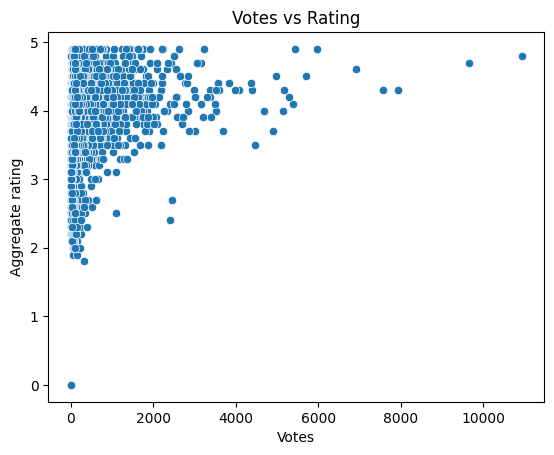

In [54]:
sns.scatterplot(x='Votes', y='Aggregate rating', data=df)
plt.title("Votes vs Rating")
plt.show()

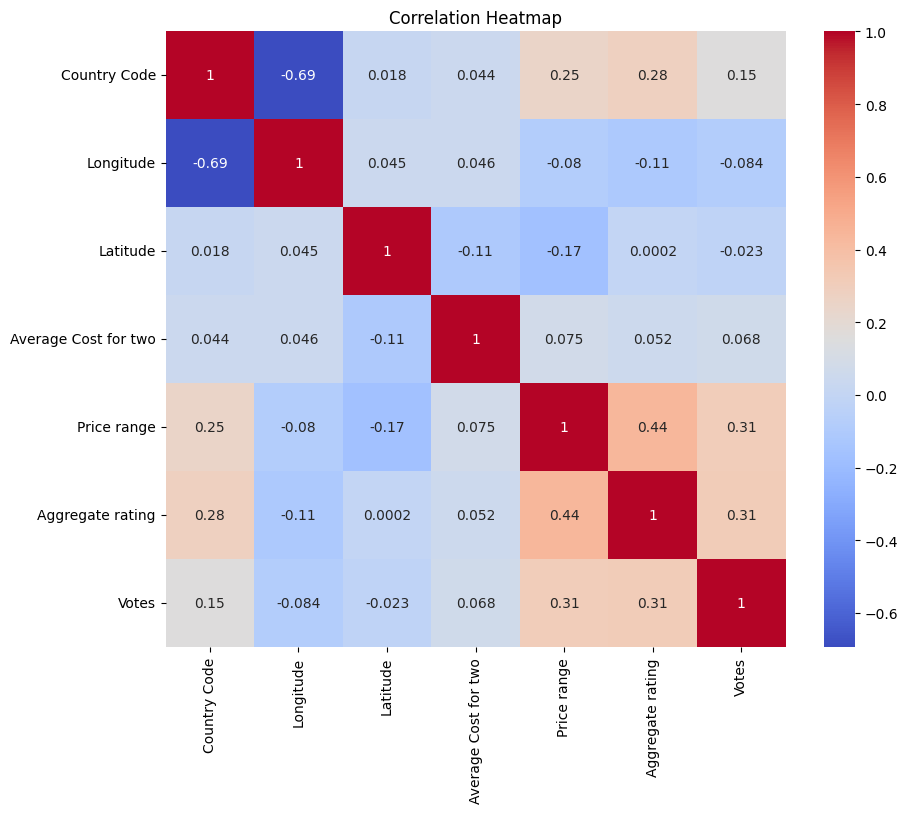

In [60]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

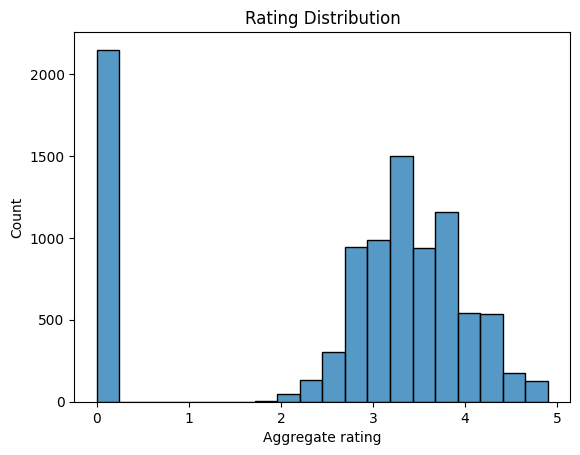

In [59]:
sns.histplot(df['Aggregate rating'], bins=20)
plt.title("Rating Distribution")
plt.show()

### 🔄 Converting Categorical Values

We convert Yes/No values into numeric format for machine learning.

In [61]:
df['Has Table booking'] = df['Has Table booking'].map({'Yes':1, 'No':0})
df['Has Online delivery'] = df['Has Online delivery'].map({'Yes':1, 'No':0})
df['Is delivering now'] = df['Is delivering now'].map({'Yes':1, 'No':0})

### 🔢 Encoding Remaining Categorical Features

We convert all remaining text columns into numerical values.

In [62]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

## 📊 Splitting the Dataset

We divide the dataset into training and testing sets.

In [63]:
from sklearn.model_selection import train_test_split

X = df.drop('Aggregate rating', axis=1)
y = df['Aggregate rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 🤖 Model Training

We train regression models to predict restaurant ratings.

In [64]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

lr = LinearRegression()
lr.fit(X_train, y_train)

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [65]:
from sklearn.model_selection import train_test_split

X = df.drop('Aggregate rating', axis=1)
y = df['Aggregate rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

## 📈 Model Evaluation

We evaluate the performance of models using Mean Squared Error (MSE) and R² score.

In [66]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate(model, name):
    y_pred = model.predict(X_test)
    print(name)
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))
    print("-----------")

evaluate(lr, "Linear Regression")
evaluate(dt, "Decision Tree")

Linear Regression
MSE: 1.5173235142845116
R2: 0.33742262945924484
-----------
Decision Tree
MSE: 0.17437401781037193
R2: 0.9238552114142226
-----------


## 🔍 Feature Importance Analysis

We analyze which features influence restaurant ratings the most.

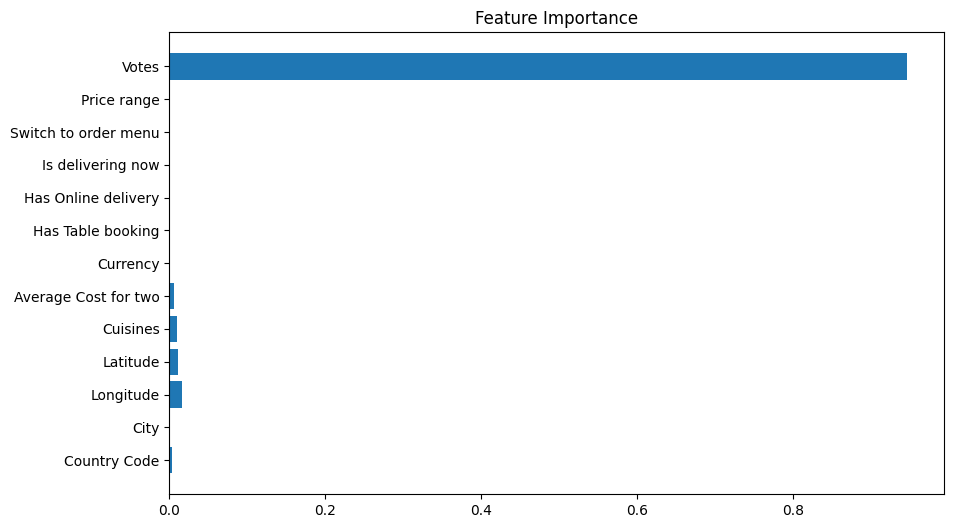

In [67]:
importance = dt.feature_importances_

plt.figure(figsize=(10,6))
plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.show()

## 📊 Interpretation of Results

- Decision Tree model performs better than Linear Regression.
- Votes have the strongest influence on ratings.
- Price and delivery features have moderate to low impact.

This shows how machine learning can identify important factors affecting restaurant ratings.

## 📌 Conclusion

- Decision Tree model performed better than Linear Regression.
- Votes have the strongest influence on restaurant ratings.
- Price and other features have moderate impact.
- The model successfully predicts restaurant ratings based on given features.

This project demonstrates how machine learning can be used to analyze and predict real-world data.